#Email Spam Detector
A text classifier to detect spam emails using Naive Bayes text classification assisted by TF-IDF.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [51]:
#Initial look at the dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [52]:
#Finding number of messages
df.shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 5572
Number of columns: 5


In [53]:
#Dropping the "unnamed" columns as only columns v1 and v2 are required
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [54]:
#Renaming columns to have meaningful names instead of v1,v2
df = df.rename(columns={"v1":"label", "v2":"message"})
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64


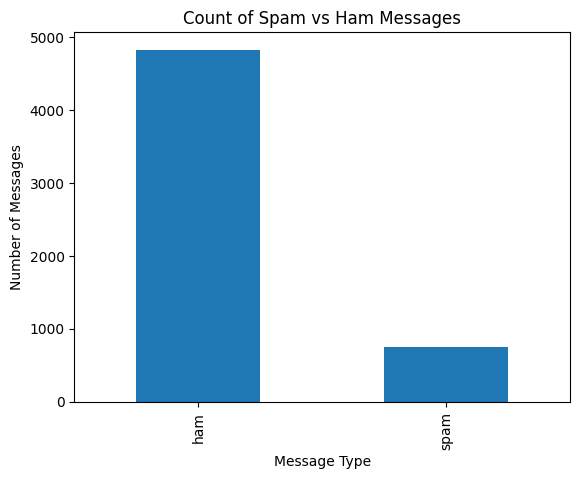

In [55]:
#Counting number of spam vs ham messages
count = df["label"].value_counts();
print(count)
count.plot(kind='bar')
plt.title('Count of Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

In [56]:
#creating a new column for length of each message and to find avg length of spam and ham messages (could be an indicator)
df['length'] = df['message'].str.len()
avgMsgLength = df.groupby('label')['length'].mean()
print(avgMsgLength)

label
ham      71.023627
spam    138.866131
Name: length, dtype: float64


Text(0, 0.5, 'Number of messages')

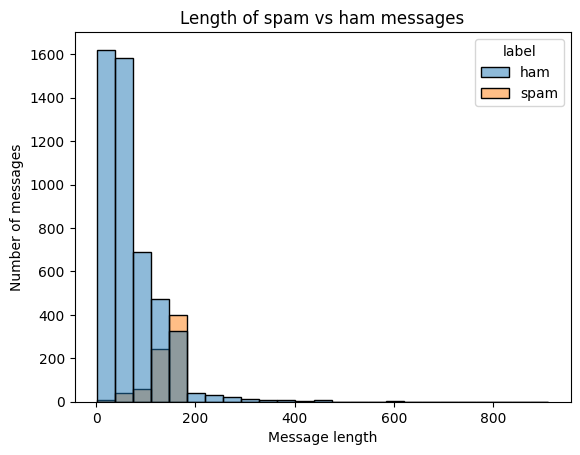

In [57]:
#Visualization group messages by length
sns.histplot(data = df, x = "length", hue = "label", bins = 25, alpha = 0.5)
plt.title('Length of spam vs ham messages')
plt.xlabel('Message length')
plt.ylabel('Number of messages')

In [58]:
#Converting each message to lower case for uniformity and removing all punctuation to reduce clutter
df['message'] = df['message'].str.lower()
df['message'] = df['message'].str.replace(r'[^\w\s]', '', regex=True)

#removing stopwords
nltk.download('stopwords')
stopWordsSet = set(stopwords.words('english'))
def removeStopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stopWordsSet]
    return " ".join(filtered)
df['message'] = df['message'].apply(removeStopwords)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,length
0,ham,go jurong point crazy available bugis n great ...,111
1,ham,ok lar joking wif u oni,29
2,spam,free entry 2 wkly comp win fa cup final tkts 2...,155
3,ham,u dun say early hor u c already say,49
4,ham,nah dont think goes usf lives around though,61


In [59]:
#applying TF-IDF
tfidfObj = TfidfVectorizer(max_features = 3000)
tfidfMatrix = tfidfObj.fit_transform(df["message"])
tfidfMatrix.shape
print(f"Number of rows: {tfidfMatrix.shape[0]}")
print(f"Number of columns: {tfidfMatrix.shape[1]}")

Number of rows: 5572
Number of columns: 3000


In [60]:
#Splitting data into training and testing sets
x = tfidfMatrix
y = df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
#Verifying the split has been done right
print(f"Number of rows in x_train: {x_train.shape[0]}")
print(f"Number of rows in x_test: {x_test.shape[0]}")
print(f"Number of rows in y_train: {y_train.shape[0]}")
print(f"Number of rows in y_test: {y_test.shape[0]}")

Number of rows in x_train: 4457
Number of rows in x_test: 1115
Number of rows in y_train: 4457
Number of rows in y_test: 1115


In [61]:
#Training the model on Naive Bayes using MultinomialNB
nbObj = MultinomialNB()
nbModel = nbObj.fit(x_train, y_train)
result = nbModel.predict(x_test)
#Checking results
accuracyNB = accuracy_score(y_test, result)
print(f"Accuracy: {accuracyNB}")
print("Classification report:")
print(classification_report(y_test, result))
print("Confusion matrix")
print(confusion_matrix(y_test, result))

Accuracy: 0.979372197309417
Classification report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       1.00      0.85      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion matrix
[[965   0]
 [ 23 127]]


In [62]:
#Training a logistic regression model
lrObj = LogisticRegression()
lrModel = lrObj.fit(x_train, y_train)
result = lrModel.predict(x_test)
#Checking results
accuracyLR = accuracy_score(y_test, result)
print(f"Accuracy: {accuracyLR}")
print("Classification report:")
print(classification_report(y_test, result))
print("Confusion matrix")
print(confusion_matrix(y_test, result))

Accuracy: 0.9533632286995516
Classification report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       965
        spam       0.96      0.68      0.80       150

    accuracy                           0.95      1115
   macro avg       0.96      0.84      0.89      1115
weighted avg       0.95      0.95      0.95      1115

Confusion matrix
[[961   4]
 [ 48 102]]


On comparing both, the Naive Bayes model and the Logistic Regression model, we can clearly see that the Naive Bayes model outperforms the Logistic Regression model as on comparing the results the precision, recall and F1 score of the Naive Bayes model is higher than that of the Logistic Regression model clearly indicating that the Naive Bayes model is better suited for this scenario.

In [63]:
#Extracting the top 20 words occuring in spam messages
featureNames = tfidfObj.get_feature_names_out() #list of all words occuring in spam messages
nbModel.feature_log_prob_ #log probability of a word occuring in ham and spam messages
#finding the most commonly occuring words from spam messages
mostProbWordsAscending = np.argsort(nbModel.feature_log_prob_[1])
mostProbWordsDescending = mostProbWordsAscending[::-1]
mostProb20Words = mostProbWordsDescending[:20]#extracting top 20 word indexes
print(featureNames[mostProb20Words])#mapping those indexes to words

['call' 'free' 'txt' 'claim' 'mobile' 'stop' 'text' 'prize' 'ur' 'reply'
 'new' 'urgent' 'cash' 'please' 'nokia' 'get' 'win' 'service' 'contact'
 'send']
